In [ ]:
import os
from google.colab import files
import pandas as pd
import numpy as np

print("=" * 60)
print("🚀 TP53 MUTATION DATA PROCESSING")
print("=" * 60)


🚀 TP53 MUTATION DATA PROCESSING


In [ ]:
import os

# Define a flag to control upload
should_upload = True

# Check if TP53_FILE is already defined and the file exists on the disk
# This handles cases where the notebook is run non-linearly or after a previous run
if 'TP53_FILE' in locals() and TP53_FILE is not None and os.path.exists(TP53_FILE):
    print(f'✅ Found previously uploaded file: "{TP53_FILE}". Skipping upload.')
    should_upload = False
else:
    # Clear TP53_FILE if it exists but the file does not, to ensure fresh upload
    if 'TP53_FILE' in locals():
        del TP53_FILE

if should_upload:
    print('\n📤 Please upload your CSV file when prompted...')
    uploaded = files.upload()

    if uploaded:
        # Assuming only one file is uploaded and it's the TP53 data
        for fn in uploaded.keys():
            print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
            TP53_FILE = fn
        print(f'\n✅ Successfully uploaded: {TP53_FILE}')
    else:
        print('\n❌ No new file was uploaded. Please try again.')
        # If no file was uploaded, and it wasn't previously set, then TP53_FILE might not be defined.
        # This can lead to errors in subsequent cells. Let's ensure it's None.
        if 'TP53_FILE' not in locals():
            TP53_FILE = None

# Final check to ensure TP53_FILE exists before proceeding, otherwise warn
if 'TP53_FILE' not in locals() or TP53_FILE is None or not os.path.exists(TP53_FILE):
    print("⚠️ Warning: TP53_FILE is not set or does not exist. Subsequent cells may fail.")


✅ Found previously uploaded file: "Cosmic_GenomeScreensMutant_Tsv_v104_GRCh38.csv". Skipping upload.


In [ ]:
# Get the uploaded filename
import os
uploaded_files = list(uploaded.keys())
filename = uploaded_files[0]

# Load the data
print(f"\n📂 Loading file: {filename}")
df = pd.read_csv(filename)

print(f"\n✅ Loaded {len(df):,} rows")
print(f"✅ Loaded {len(df.columns)} columns")
print(f"\n📊 Column names:")
for col in df.columns:
    print(f"  - {col}")

# Show first few rows
print("\n🔍 First 5 rows:")
df.head()


📂 Loading file: Cosmic_GenomeScreensMutant_Tsv_v104_GRCh38.csv


/tmp/ipykernel_2739/1526590491.py:8: DtypeWarning: Columns (12,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)



✅ Loaded 359,096 rows
✅ Loaded 27 columns

📊 Column names:
  - GENE_SYMBOL
  - COSMIC_GENE_ID
  - TRANSCRIPT_ACCESSION
  - COSMIC_SAMPLE_ID
  - SAMPLE_NAME
  - COSMIC_PHENOTYPE_ID
  - GENOMIC_MUTATION_ID
  - LEGACY_MUTATION_ID
  - MUTATION_ID
  - MUTATION_CDS
  - MUTATION_AA
  - MUTATION_DESCRIPTION
  - MUTATION_ZYGOSITY
  - LOH
  - GENOME_VERSION
  - CHROMOSOME
  - GENOME_START
  - GENOME_STOP
  - STRAND
  - PUBMED_PMID
  - COSMIC_STUDY_ID
  - HGVSP
  - HGVSC
  - HGVSG
  - GENOMIC_WT_ALLELE
  - GENOMIC_MUT_ALLELE
  - MUTATION_SOMATIC_STATUS

🔍 First 5 rows:


,GENE_SYMBOL,COSMIC_GENE_ID,TRANSCRIPT_ACCESSION,COSMIC_SAMPLE_ID,SAMPLE_NAME,...,HGVSC,HGVSG,GENOMIC_WT_ALLELE,GENOMIC_MUT_ALLELE,MUTATION_SOMATIC_STATUS
0,TP53,COSG115384,ENST00000269305.8,COSS1184078,PD3890a,...,ENST00000269305.8:c.742C>T,17:g.7674221G>A,G,A,Confirmed somatic variant
1,TP53,COSG115384,ENST00000269305.8,COSS1184078,PD3890a,...,ENST00000269305.8:c.742C>T,17:g.7674221G>A,G,A,Confirmed somatic variant
2,TP53,COSG115384,ENST00000269305.8,COSS1184078,PD3890a,...,ENST00000269305.8:c.742C>T,17:g.7674221G>A,G,A,Confirmed somatic variant
3,TP53,COSG115384,ENST00000269305.8,COSS1184078,PD3890a,...,ENST00000269305.8:c.742C>T,17:g.7674221G>A,G,A,Confirmed somatic variant
4,TP53,COSG115384,ENST00000359597.8,COSS1184078,PD3890a,...,ENST00000359597.8:c.742C>T,17:g.7674221G>A,G,A,Confirmed somatic variant


In [ ]:
# ============================================
# DATA EXPLORATION
# ============================================

print("\n" + "=" * 60)
print("📊 DATA EXPLORATION")
print("=" * 60)

# Basic statistics
print(f"\n📈 Basic Statistics:")
print(f"  - Total rows: {len(df):,}")
print(f"  - Unique genes: {df['GENE_SYMBOL'].nunique():,}")
print(f"  - Unique mutations: {df['MUTATION_AA'].nunique():,}")
print(f"  - Unique descriptions: {df['MUTATION_DESCRIPTION'].nunique():,}")

# Show mutation types
print(f"\n📋 Mutation types:")
for desc in df['MUTATION_DESCRIPTION'].value_counts().head(10).items():
    print(f"  - {desc[0]}: {desc[1]:,}")

# Check if all are TP53
print(f"\n✅ Gene validation:")
print(f"  - All rows are TP53? {df['GENE_SYMBOL'].nunique() == 1}")
if df['GENE_SYMBOL'].nunique() == 1:
    print(f"  - Gene: {df['GENE_SYMBOL'].iloc[0]}")


📊 DATA EXPLORATION

📈 Basic Statistics:
  - Total rows: 359,096
  - Unique genes: 1
  - Unique mutations: 8,986
  - Unique descriptions: 49

📋 Mutation types:
  - missense_variant: 216,970
  - stop_gained: 45,435
  - frameshift_variant: 26,992
  - intron_variant: 11,784
  - splice_donor_variant: 11,543
  - splice_acceptor_variant: 9,816
  - 5_prime_UTR_variant: 9,480
  - 3_prime_UTR_variant: 8,536
  - missense_variant,splice_region_variant: 4,494
  - inframe_deletion: 3,726

✅ Gene validation:
  - All rows are TP53? True
  - Gene: TP53


In [ ]:
# ============================================
# FILTER FOR MISSENSE AND SPLICE VARIANTS
# ============================================

print("\n" + "=" * 60)
print("🔍 FILTERING VARIANTS")
print("=" * 60)

# Filter for missense and splice variants
filtered_df = df[
    df['MUTATION_DESCRIPTION'].str.contains('missense|splice', na=False, case=False)
]

print(f"\n📊 Before filtering: {len(df):,} rows")
print(f"📊 After filtering: {len(filtered_df):,} rows")
print(f"📊 Unique mutations after filtering: {filtered_df['MUTATION_AA'].nunique():,}")

# Show what was kept
print(f"\n📋 Mutation types kept:")
for desc in filtered_df['MUTATION_DESCRIPTION'].value_counts().items():
    print(f"  - {desc[0]}: {desc[1]:,}")


🔍 FILTERING VARIANTS

📊 Before filtering: 359,096 rows
📊 After filtering: 249,534 rows
📊 Unique mutations after filtering: 3,399

📋 Mutation types kept:
  - missense_variant: 216,970
  - splice_donor_variant: 11,543
  - splice_acceptor_variant: 9,816
  - missense_variant,splice_region_variant: 4,494
  - splice_region_variant,stop_gained: 1,724
  - splice_region_variant,synonymous_variant: 1,603
  - frameshift_variant,splice_region_variant: 803
  - intron_variant,splice_region_variant: 769
  - coding_sequence_variant,intron_variant,splice_acceptor_variant: 343
  - coding_sequence_variant,intron_variant,splice_donor_variant: 258
  - inframe_deletion,splice_region_variant: 249
  - coding_sequence_variant,splice_acceptor_variant: 186
  - intron_variant,splice_acceptor_variant: 182
  - 5_prime_UTR_variant,splice_region_variant: 137
  - intron_variant,splice_donor_variant: 103
  - coding_sequence_variant,splice_donor_variant: 100
  - 3_prime_UTR_variant,splice_region_variant: 63
  - coding_

In [ ]:
# ============================================
# UNIQUE MUTATIONS & FREQUENCIES
# ============================================

print("\n" + "=" * 60)
print("📊 MUTATION FREQUENCY ANALYSIS")
print("=" * 60)

# Get unique mutations
unique_mutations = filtered_df['MUTATION_AA'].unique()
print(f"\n✅ Total unique mutations: {len(unique_mutations):,}")

# Count frequencies
mutation_counts = filtered_df['MUTATION_AA'].value_counts()

print(f"\n🔥 Top 20 most common mutations:")
print("-" * 50)
for i, (mutation, count) in enumerate(mutation_counts.head(20).items(), 1):
    print(f"{i:2d}. {mutation:15s} - {count:4d} occurrences")

# Summary statistics
print(f"\n📊 Frequency statistics:")
print(f"  - Max occurrences: {mutation_counts.max()}")
print(f"  - Min occurrences: {mutation_counts.min()}")
print(f"  - Mean occurrences: {mutation_counts.mean():.1f}")
print(f"  - Median occurrences: {mutation_counts.median():.1f}")


📊 MUTATION FREQUENCY ANALYSIS

✅ Total unique mutations: 3,399

🔥 Top 20 most common mutations:
--------------------------------------------------
 1. p.?             - 23687 occurrences
 2. p.R175H         - 5866 occurrences
 3. p.R136H         - 4190 occurrences
 4. p.R248Q         - 3717 occurrences
 5. p.R273C         - 2886 occurrences
 6. p.R248W         - 2723 occurrences
 7. p.R273H         - 2694 occurrences
 8. p.R209Q         - 2655 occurrences
 9. p.R282W         - 2604 occurrences
10. p.R16H          - 2514 occurrences
11. p.R43H          - 2514 occurrences
12. p.R234C         - 2405 occurrences
13. p.R234H         - 2245 occurrences
14. p.R243W         - 2170 occurrences
15. p.Y220C         - 1967 occurrences
16. p.R209W         - 1945 occurrences
17. p.G245S         - 1799 occurrences
18. p.R89Q          - 1593 occurrences
19. p.R116Q         - 1593 occurrences
20. p.R114C         - 1443 occurrences

📊 Frequency statistics:
  - Max occurrences: 23687
  - Min occurrences

In [ ]:
import pandas as pd

print("\n" + "=" * 60)
print("🎯 FILTERING BY FREQUENCY")
print("=" * 60)

# First, count how often each mutation appears within the already filtered data
mutation_counts = filtered_df['MUTATION_AA'].value_counts()

# Choose your frequency threshold
min_freq = 10  # Change this number to adjust

frequent_mutations = mutation_counts[mutation_counts >= min_freq].index.tolist()
frequent_df = filtered_df[filtered_df['MUTATION_AA'].isin(frequent_mutations)]

print(f"\n📊 Total unique mutations in filtered_df: {len(mutation_counts):,}")
print(f"📊 Mutations appearing \u2265{min_freq} times (after filtering missense/splice): {len(frequent_mutations):,}")
print(f"📊 Rows for frequent mutations: {len(frequent_df):,}")

# Show the frequent mutations
print(f"\n\U0001f525 Frequent mutations (\u2265{min_freq} occurrences):")
print("-" * 50)
# Ensure we only show mutations that actually meet the min_freq threshold
for mutation, count in mutation_counts[mutation_counts >= min_freq].items():
    print(f"  {mutation}: {count} occurrences")

# Use frequent_df for analysis to retain all occurrences for correct counting
df_to_analyze = frequent_df

print(f"\n\u2705 Dataset for analysis (all occurrences meeting frequency threshold): {len(df_to_analyze):,}")


🎯 FILTERING BY FREQUENCY

📊 Total unique mutations in filtered_df: 3,399
📊 Mutations appearing ≥10 times (after filtering missense/splice): 1,844
📊 Rows for frequent mutations: 243,248

🔥 Frequent mutations (≥10 occurrences):
--------------------------------------------------
  p.?: 23687 occurrences
  p.R175H: 5866 occurrences
  p.R136H: 4190 occurrences
  p.R248Q: 3717 occurrences
  p.R273C: 2886 occurrences
  p.R248W: 2723 occurrences
  p.R273H: 2694 occurrences
  p.R209Q: 2655 occurrences
  p.R282W: 2604 occurrences
  p.R16H: 2514 occurrences
  p.R43H: 2514 occurrences
  p.R234C: 2405 occurrences
  p.R234H: 2245 occurrences
  p.R243W: 2170 occurrences
  p.Y220C: 1967 occurrences
  p.R209W: 1945 occurrences
  p.G245S: 1799 occurrences
  p.R89Q: 1593 occurrences
  p.R116Q: 1593 occurrences
  p.R114C: 1443 occurrences
  p.R141C: 1443 occurrences
  p.Y181C: 1405 occurrences
  p.R114H: 1347 occurrences
  p.R141H: 1347 occurrences
  p.R150W: 1302 occurrences
  p.R123W: 1302 occurrences


☑️ Directory 'TP53_Mutation_Analysis' already exists.

🔬 RUNNING MAIN ANALYSIS ON FILTERED DATA
✅ Using filtered dataset (df_to_analyze)

📊 Dataset summary:
   Total entries: 243,248
   Unique samples: 12,775
   Unique protein mutations: 1,844

🏆 TOP 20 TP53 MUTATIONS
            p.? : 1407 samples
         p.R43H :  817 samples
        p.R136H :  817 samples
         p.R16H :  817 samples
        p.R164H :  817 samples
        p.R175H :  817 samples
        p.R237Q :  521 samples
        p.R116Q :  521 samples
         p.R89Q :  521 samples
        p.R209Q :  521 samples
        p.R248Q :  521 samples
        p.R141C :  473 samples
        p.R273C :  473 samples
        p.R234C :  473 samples
        p.R114C :  473 samples
        p.R262C :  473 samples
        p.R273H :  436 samples
        p.R114H :  436 samples
        p.R234H :  436 samples
        p.R262H :  436 samples

📊 MUTATION TYPE DISTRIBUTION
                   missense_variant : 211573 (87.0%))
               splice_donor

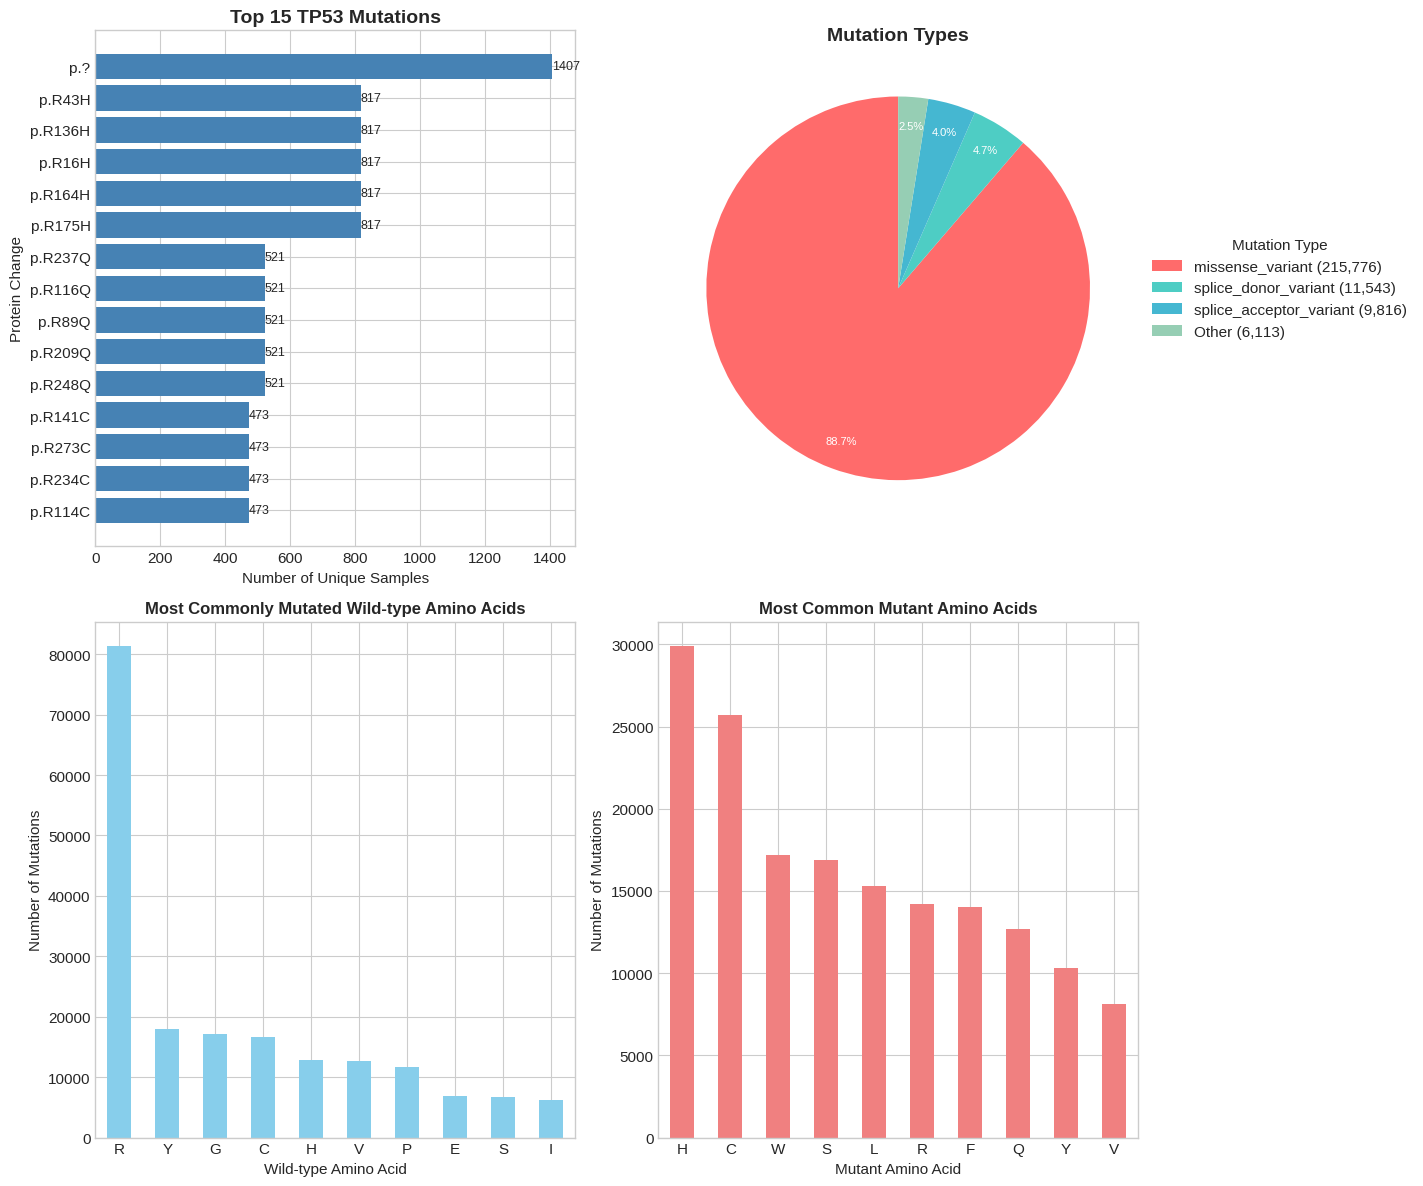


🔥 MUTATION HOTSPOT ANALYSIS

Top 10 mutation positions:
  Position 248: 6881 mutations
  Position 234: 6629 mutations
  Position 175: 6613 mutations
  Position 273: 6480 mutations
  Position 209: 5200 mutations
  Position 136: 4538 mutations
  Position 141: 4032 mutations
  Position 116: 3603 mutations
  Position 114: 3537 mutations
  Position 245: 3347 mutations

Positions 175-282 (DNA-binding domain) mutations:
  104086 mutations in DNA-binding domain (47.8%)

🚫 Nonsense/truncating mutations: 1716 (0.7%)
Top nonsense mutations:
MUTATION_AA
p.Q331*    468
p.Q292*    390
p.Q199*    234
p.Q172*    234
p.Y126*     98
p.Q320*     78
p.Y87*      70
p.E224*     56
p.E185*     40
p.E92*      24
Name: count, dtype: int64

✂️ Splice variants: 31675 (13.0%)
Top splice mutations:

MUTATION_AA
p.?        23687
p.T125=      651
p.Q331*      468
p.T86=       465
p.Y126H      455
p.Q292*      390
p.Y87H       325
p.T125M      266
p.Q199*      234
p.Q172*      234
Name: count, dtype: int64

✅ ANALYS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = 'TP53_Mutation_Analysis'

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Created directory: '{output_dir}'")
else:
    print(f"☑️ Directory '{output_dir}' already exists.")

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("\n" + "=" * 60)
print("🔬 RUNNING MAIN ANALYSIS ON FILTERED DATA")
print("=" * 60)

# Check if df_to_analyze exists, if not use the original df
try:
    df_analysis = df_to_analyze
    print("✅ Using filtered dataset (df_to_analyze)")
except NameError:
    df_analysis = df
    print("⚠️ df_to_analyze not found, using original dataset (df)")

# If df_analysis is empty, use original df
if len(df_analysis) == 0:
    print("⚠️ Filtered dataset is empty, using original dataset (df)")
    df_analysis = df

print(f"\n📊 Dataset summary:")
print(f"   Total entries: {len(df_analysis):,}")
print(f"   Unique samples: {df_analysis['COSMIC_SAMPLE_ID'].nunique():,}")
print(f"   Unique protein mutations: {df_analysis['MUTATION_AA'].nunique():,}")

# 1. Find unique mutations and their frequency (unique sample count)
unique_mutations = df_analysis.groupby('MUTATION_AA')['COSMIC_SAMPLE_ID'].nunique().reset_index()
unique_mutations.columns = ['MUTATION_AA', 'SAMPLE_COUNT']
top_mutations = unique_mutations.sort_values('SAMPLE_COUNT', ascending=False).head(20)

print("\n" + "=" * 60)
print("🏆 TOP 20 TP53 MUTATIONS")
print("=" * 60)
for i, row in top_mutations.iterrows():
    print(f"{row['MUTATION_AA']:>15} : {row['SAMPLE_COUNT']:>4} samples")

# 2. Create the plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Top 15 mutations
ax1 = axes[0, 0]
top15 = top_mutations.head(15)
bars = ax1.barh(top15['MUTATION_AA'], top15['SAMPLE_COUNT'], color='steelblue')
ax1.set_xlabel('Number of Unique Samples')
ax1.set_ylabel('Protein Change')
ax1.set_title('Top 15 TP53 Mutations', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(width)), ha='left', va='center', fontsize=9)

# Plot 2: Mutation type distribution (Pie Chart) - Improved readability
ax2 = axes[0, 1]
mutation_types_counts = df_analysis['MUTATION_DESCRIPTION'].value_counts()
simple_types_counts = df_analysis['MUTATION_DESCRIPTION'].str.split(',').str[0].value_counts()

# Group small percentages into 'Other' for improved readability
threshold_percent_pie = 1.5 # Combine categories smaller than this percentage
total_mutations_pie = simple_types_counts.sum()
simple_types_percent = (simple_types_counts / total_mutations_pie) * 100

main_types_pie = simple_types_percent[simple_types_percent >= threshold_percent_pie]
other_types_count_pie = simple_types_percent[simple_types_percent < threshold_percent_pie].sum()

plot_simple_types = main_types_pie.copy()
if other_types_count_pie > 0:
    plot_simple_types['Other'] = other_types_count_pie

# Custom autopct function to hide percentages below a certain threshold
def autopct_format_analysis(pct):
    return ('%1.1f%%' % pct) if pct > threshold_percent_pie else ''

colors_analysis_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FF9999']

wedges, texts, autotexts = ax2.pie(
    plot_simple_types.values, # Use the grouped data
    labels=None, # Explicitly disable default labels
    autopct=autopct_format_analysis, # Use custom format function
    startangle=90,
    colors=colors_analysis_pie[:len(plot_simple_types)],
    pctdistance=0.85 # Distance of percentage labels from center
)

# Set properties for autotexts (percentages)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)

ax2.set_title('Mutation Types', fontsize=14, fontweight='bold')
ax2.set_ylabel('') # Remove default 'count' label

# Create legend outside the pie chart
legend_labels_analysis = []
for label, value in plot_simple_types.items():
    if label == 'Other':
        other_sum_count = simple_types_counts[simple_types_percent < threshold_percent_pie].sum()
        # Find the original sum of counts for the 'Other' category
        original_other_sum = simple_types_counts[simple_types_percent < threshold_percent_pie].values.sum()
        legend_labels_analysis.append(f'{label} ({int(original_other_sum):,})')
    else:
        original_count = simple_types_counts[simple_types_counts.index == label].iloc[0]
        legend_labels_analysis.append(f'{label} ({int(original_count):,})')

ax2.legend(wedges, legend_labels_analysis,
           title="Mutation Type",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

print("\n" + "=" * 60)
print("📊 MUTATION TYPE DISTRIBUTION")
print("=" * 60)
for mut_type, count in mutation_types_counts.items():
    print(f"{mut_type:>35} : {count:>5} ({count/len(df_analysis)*100:.1f}%))")

# Plot 3: Most commonly mutated wild-type amino acids
ax3 = axes[1, 0]
# Extract amino acid changes from MUTATION_AA
aa_changes = df_analysis['MUTATION_AA'].str.extract(r'p\.([A-Z])(\d+)([A-Z\*])')
aa_changes.columns = ['WT_AA', 'POSITION', 'MUTANT_AA']
aa_changes = aa_changes.dropna()
aa_changes['POSITION'] = aa_changes['POSITION'].astype(int)

if len(aa_changes) > 0:
    wt_aa_counts = aa_changes['WT_AA'].value_counts().head(10)
    wt_aa_counts.plot(kind='bar', ax=ax3, color='skyblue')
    ax3.set_xlabel('Wild-type Amino Acid')
    ax3.set_ylabel('Number of Mutations')
    ax3.set_title('Most Commonly Mutated Wild-type Amino Acids', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=0)

    # Plot 4: Most common mutant amino acids
    ax4 = axes[1, 1]
    mut_aa_counts = aa_changes['MUTANT_AA'].value_counts().head(10)
    mut_aa_counts.plot(kind='bar', ax=ax4, color='lightcoral')
    ax4.set_xlabel('Mutant Amino Acid')
    ax4.set_ylabel('Number of Mutations')
    ax4.set_title('Most Common Mutant Amino Acids', fontsize=12, fontweight='bold')
    ax4.tick_params(axis='x', rotation=0)
else:
    # If no AA changes could be parsed, show a message
    ax3.text(0.5, 0.5, 'No amino acid changes found to analyze',
             ha='center', va='center', transform=ax3.transAxes)
    ax4.text(0.5, 0.5, 'No amino acid changes found to analyze',
             ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'tp53_filtered_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# 5. Hotspot analysis
if len(aa_changes) > 0:
    print("\n" + "=" * 60)
    print("🔥 MUTATION HOTSPOT ANALYSIS")
    print("=" * 60)

    position_counts = aa_changes['POSITION'].value_counts().head(20)
    print("\nTop 10 mutation positions:")
    for pos, count in position_counts.head(10).items():
        print(f"  Position {pos}: {count} mutations")

    print("\nPositions 175-282 (DNA-binding domain) mutations:")
    dbd_mutations = aa_changes[(aa_changes['POSITION'] >= 175) & (aa_changes['POSITION'] <= 282)]
    print(f"  {len(dbd_mutations)} mutations in DNA-binding domain ({len(dbd_mutations)/len(aa_changes)*100:.1f}%)")

# 6. Nonsense/truncating mutations
nonsense = df_analysis[df_analysis['MUTATION_DESCRIPTION'].str.contains('stop_gained', na=False)]
print(f"\n🚫 Nonsense/truncating mutations: {len(nonsense)} ({len(nonsense)/len(df_analysis)*100:.1f}%)")
if len(nonsense) > 0:
    print("Top nonsense mutations:")
    print(nonsense['MUTATION_AA'].value_counts().head(10))

# 7. Splice variants
splice = df_analysis[df_analysis['MUTATION_DESCRIPTION'].str.contains('splice', na=False)]
print(f"\n✂️ Splice variants: {len(splice)} ({len(splice)/len(df_analysis)*100:.1f}%)")
if len(splice) > 0:
    print("Top splice mutations:\n")
    print(splice['MUTATION_AA'].value_counts().head(10))

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE!")
print(f"📊 Check '{os.path.join(output_dir, 'tp53_filtered_analysis.png')}' for the figure.")
print("=" * 60)

In [ ]:
# ============================================
# DISPLAY KEY FINDINGS
# ============================================

import os

output_dir = 'TP53_Mutation_Analysis'

print("\n" + "=" * 60)
print("📊 TP53 MUTATION ANALYSIS - KEY FINDINGS")
print("=" * 60)

# Top mutations
print("\n🏆 TOP 10 MOST COMMON MUTATIONS:")
top10 = df_analysis['MUTATION_AA'].value_counts().head(10)
for i, (mut, count) in enumerate(top10.items(), 1):
    percentage = (count / len(df_analysis)) * 100
    print(f"  {i:2}. {mut:>12} : {count:>4} occurrences ({percentage:.1f}%)")

# Mutation types
print("\n📊 MUTATION TYPE SUMMARY:")
mutation_types = df_analysis['MUTATION_DESCRIPTION'].str.split(',').str[0].value_counts()
for mut_type, count in mutation_types.items():
    percentage = (count / len(df_analysis)) * 100
    print(f"  {mut_type:>25} : {count:>4} ({percentage:.1f}%)")

# Check if the figure was saved
figure_path = os.path.join(output_dir, 'tp53_filtered_analysis.png')
if os.path.exists(figure_path):
    print(f"\n✅ Figure saved: {figure_path} ({os.path.getsize(figure_path)/1024:.1f} KB)")
else:
    print("\n⚠️ Figure not found. Try running the analysis again.")



📊 TP53 MUTATION ANALYSIS - KEY FINDINGS

🏆 TOP 10 MOST COMMON MUTATIONS:
   1.          p.? : 23687 occurrences (9.7%)
   2.      p.R175H : 5866 occurrences (2.4%)
   3.      p.R136H : 4190 occurrences (1.7%)
   4.      p.R248Q : 3717 occurrences (1.5%)
   5.      p.R273C : 2886 occurrences (1.2%)
   6.      p.R248W : 2723 occurrences (1.1%)
   7.      p.R273H : 2694 occurrences (1.1%)
   8.      p.R209Q : 2655 occurrences (1.1%)
   9.      p.R282W : 2604 occurrences (1.1%)
  10.       p.R43H : 2514 occurrences (1.0%)

📊 MUTATION TYPE SUMMARY:
           missense_variant : 215776 (88.7%)
       splice_donor_variant : 11543 (4.7%)
    splice_acceptor_variant : 9816 (4.0%)
      splice_region_variant : 3309 (1.4%)
             intron_variant : 1054 (0.4%)
    coding_sequence_variant :  950 (0.4%)
         frameshift_variant :  278 (0.1%)
        5_prime_UTR_variant :  216 (0.1%)
           inframe_deletion :  216 (0.1%)
        3_prime_UTR_variant :   90 (0.0%)

✅ Figure saved: TP53_Mut

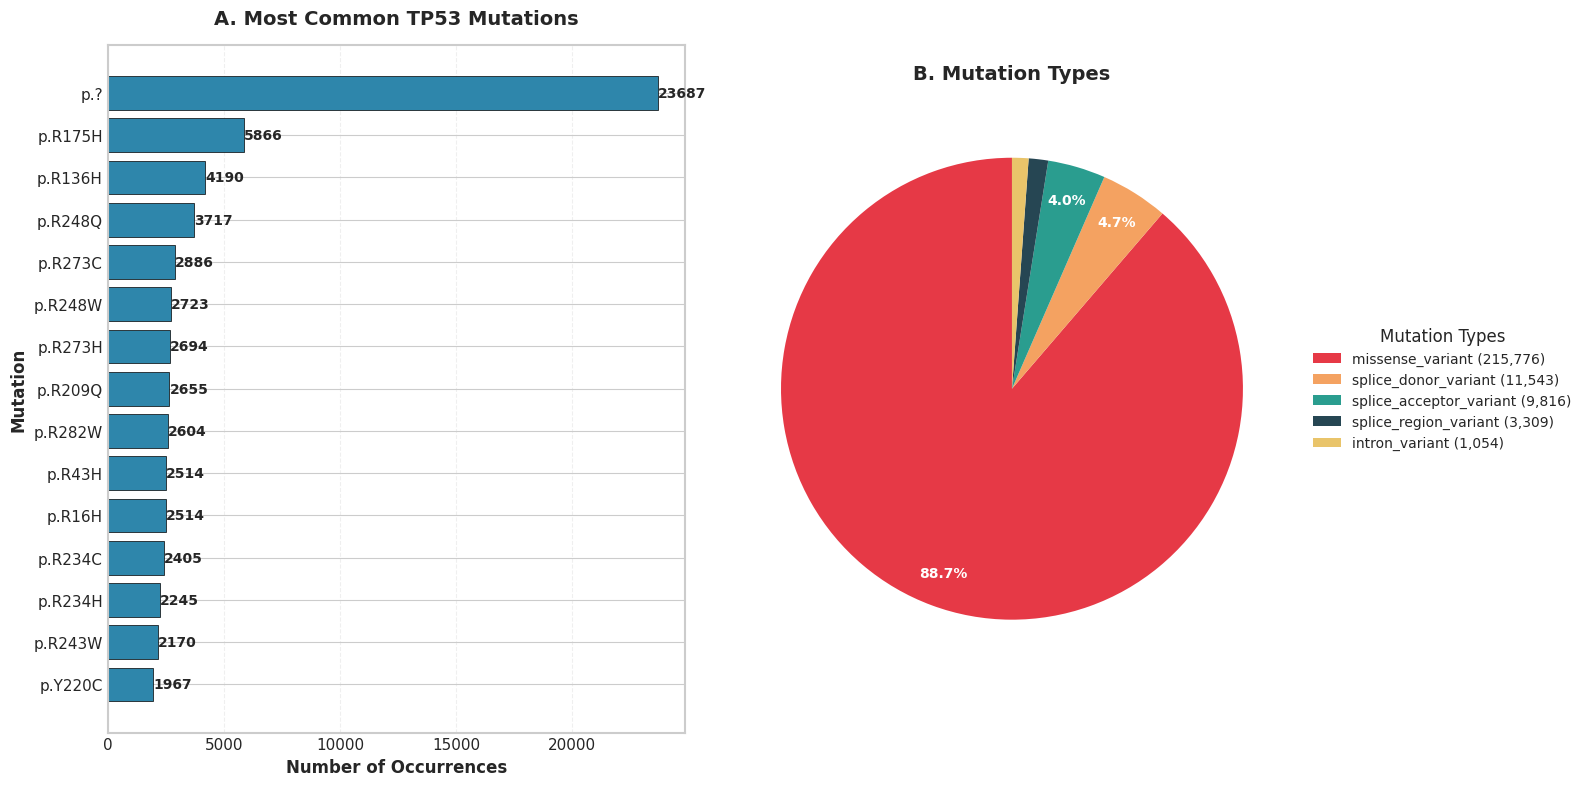

✅ Publication-ready figure saved: TP53_Mutation_Analysis/tp53_publication_figure.png


In [ ]:
# ============================================
# PUBLICATION-READY FIGURE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = 'TP53_Mutation_Analysis'

# Use a clean, scientific style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Get top 15 mutations
top_mutations = df_analysis['MUTATION_AA'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Top mutations (bar chart)
ax1 = axes[0]
bars = ax1.barh(range(len(top_mutations)), top_mutations.values,
                color='#2E86AB', edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(top_mutations)))
ax1.set_yticklabels(top_mutations.index)
ax1.set_xlabel('Number of Occurrences', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mutation', fontweight='bold', fontsize=12)
ax1.set_title('A. Most Common TP53 Mutations', fontsize=14, fontweight='bold', pad=15)
ax1.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    if width > 0:
        ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(width)), ha='left', va='center', fontsize=10, fontweight='bold')

# Add grid for readability
ax1.xaxis.grid(True, linestyle='--', alpha=0.3)

# Right plot: Mutation type distribution (Pie Chart)
ax2 = axes[1]
mutation_types = df_analysis['MUTATION_DESCRIPTION'].str.split(',').str[0].value_counts()

# Group small percentages into 'Other'
threshold_percent = 1.0 # Combine categories smaller than this percentage
total_mutations = mutation_types.sum()

# Calculate percentages for each type
mutation_types_percent = (mutation_types / total_mutations) * 100

# Separate types above and below the threshold
main_types = mutation_types_percent[mutation_types_percent >= threshold_percent]
other_types_count = mutation_types_percent[mutation_types_percent < threshold_percent].sum()

# Create a new series for plotting
plot_mutation_types = main_types.copy()
if other_types_count > 0:
    plot_mutation_types['Other'] = other_types_count

# Sort for consistent plotting (optional, but good practice)
plot_mutation_types = plot_mutation_types.sort_values(ascending=False)

colors_publication_pie = ['#E63946', '#F4A261', '#2A9D8F', '#264653', '#E9C46A', '#8ECAE6']

# Custom autopct function to hide percentages below a certain threshold
def autopct_format(pct):
    return ('%1.1f%%' % pct) if pct > 1.5 else '' # Only show if > 1.5% of total

wedges, texts, autotexts = ax2.pie(
    plot_mutation_types.values,
    labels=None, # Explicitly disable default labels to prevent '1's
    autopct=autopct_format, # Use custom format function
    startangle=90,
    colors=colors_publication_pie[:len(plot_mutation_types)],
    pctdistance=0.85
)

# Adjust autotexts (percentages) style
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax2.set_title('B. Mutation Types', fontsize=14, fontweight='bold', pad=15)

# Create legend outside the pie chart with labels and percentages
# Use the original mutation_types for the legend to show full detail
legend_labels_publication = [f'{label} ({value:,})' for label, value in mutation_types.items()]
ax2.legend(wedges, legend_labels_publication,
           title="Mutation Types",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10,
           title_fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'tp53_publication_figure.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Publication-ready figure saved: {os.path.join(output_dir, 'tp53_publication_figure.png')}")

In [ ]:
# ============================================
# GENERATE STATISTICAL SUMMARY TABLE
# ============================================

import pandas as pd
import os

output_dir = 'TP53_Mutation_Analysis'

# Create a summary dataframe
summary_data = []

# Top 10 mutations
top10 = df_analysis['MUTATION_AA'].value_counts().head(10)
for mut, count in top10.items():
    summary_data.append({
        'Category': 'Top Mutation',
        'Name': mut,
        'Count': count,
        'Percentage': f"{(count/len(df_analysis)*100):.1f}%"
    })

# Mutation types
types = df_analysis['MUTATION_DESCRIPTION'].str.split(',').str[0].value_counts()
for mut_type, count in types.items():
    summary_data.append({
        'Category': 'Mutation Type',
        'Name': mut_type,
        'Count': count,
        'Percentage': f"{(count/len(df_analysis)*100):.1f}%"
    })

# Create dataframe
summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 60)
print("📊 STATISTICAL SUMMARY TABLE")
print("=" * 60)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv(os.path.join(output_dir, 'tp53_summary_stats.csv'), index=False)
print(f"\n✅ Summary saved: {os.path.join(output_dir, 'tp53_summary_stats.csv')}")


📊 STATISTICAL SUMMARY TABLE
     Category                    Name  Count Percentage
 Top Mutation                     p.?  23687       9.7%
 Top Mutation                 p.R175H   5866       2.4%
 Top Mutation                 p.R136H   4190       1.7%
 Top Mutation                 p.R248Q   3717       1.5%
 Top Mutation                 p.R273C   2886       1.2%
 Top Mutation                 p.R248W   2723       1.1%
 Top Mutation                 p.R273H   2694       1.1%
 Top Mutation                 p.R209Q   2655       1.1%
 Top Mutation                 p.R282W   2604       1.1%
 Top Mutation                  p.R43H   2514       1.0%
Mutation Type        missense_variant 215776      88.7%
Mutation Type    splice_donor_variant  11543       4.7%
Mutation Type splice_acceptor_variant   9816       4.0%
Mutation Type   splice_region_variant   3309       1.4%
Mutation Type          intron_variant   1054       0.4%
Mutation Type coding_sequence_variant    950       0.4%
Mutation Type      

In [ ]:
# ============================================
# EXPORT DATA FOR EXTERNAL ANALYSIS
# ============================================

import os

output_dir = 'TP53_Mutation_Analysis'

# 1. Export the filtered dataset
df_analysis.to_csv(os.path.join(output_dir, 'tp53_filtered_mutations.csv'), index=False)
print(f"✅ Filtered mutations saved: {os.path.join(output_dir, 'tp53_filtered_mutations.csv')}")

# 2. Export mutation frequency table
mutation_freq = df_analysis['MUTATION_AA'].value_counts().reset_index()
mutation_freq.columns = ['Mutation', 'Count']
mutation_freq['Percentage'] = (mutation_freq['Count'] / len(df_analysis) * 100).round(2)
mutation_freq.to_csv(os.path.join(output_dir, 'tp53_mutation_frequencies.csv'), index=False)
print(f"✅ Mutation frequencies saved: {os.path.join(output_dir, 'tp53_mutation_frequencies.csv')}")

# 3. Export sample-level summary
sample_summary = df_analysis.groupby('COSMIC_SAMPLE_ID').agg({
    'MUTATION_AA': lambda x: ', '.join(x.unique()),
    'MUTATION_DESCRIPTION': lambda x: ', '.join(x.unique())
}).reset_index()
sample_summary.to_csv(os.path.join(output_dir, 'tp53_sample_summary.csv'), index=False)
print(f"✅ Sample summary saved: {os.path.join(output_dir, 'tp53_sample_summary.csv')}")

✅ Filtered mutations saved: TP53_Mutation_Analysis/tp53_filtered_mutations.csv
✅ Mutation frequencies saved: TP53_Mutation_Analysis/tp53_mutation_frequencies.csv
✅ Sample summary saved: TP53_Mutation_Analysis/tp53_sample_summary.csv


In [ ]:
# ============================================
# CREATE OUTPUT DIRECTORY
# ============================================
import os

output_dir = 'TP53_Mutation_Analysis'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Created directory: '{output_dir}'")
else:
    print(f"☑️ Directory '{output_dir}' already exists.")

☑️ Directory 'TP53_Mutation_Analysis' already exists.


All subsequent output files (plots, CSVs, FASTA, TXT) will now be saved into the `TP53_Mutation_Analysis` folder.

In [ ]:
# ============================================
# LIST ALL GENERATED FILES
# ============================================

import os

output_dir = 'TP53_Mutation_Analysis'
print(f"\nAll generated files in '{output_dir}':")
if os.path.exists(output_dir):
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            print(f"  - {os.path.join(root, file)}")
else:
    print(f"  ⚠️ Directory '{output_dir}' not found. Please ensure files were generated.")



All generated files in 'TP53_Mutation_Analysis':
  - TP53_Mutation_Analysis/tp53_mutant_sequences.fasta
  - TP53_Mutation_Analysis/tp53_filtered_mutations.csv
  - TP53_Mutation_Analysis/tp53_mutant_sequences.txt
  - TP53_Mutation_Analysis/tp53_filtered_analysis.png
  - TP53_Mutation_Analysis/tp53_publication_figure.png
  - TP53_Mutation_Analysis/tp53_summary_stats.csv
  - TP53_Mutation_Analysis/tp53_mutation_frequencies.csv
  - TP53_Mutation_Analysis/tp53_sample_summary.csv


In [ ]:
import re
import os

output_dir = 'TP53_Mutation_Analysis'

WT_TP53_SEQUENCE = "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPGGSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD"

def apply_all_mutations(wt_sequence, mutation_str):
    """Handle ALL mutation types from COSMIC."""
    if not mutation_str.startswith('p.'):
        return None

    part = mutation_str[2:]

    # Skip unknowns
    if part in ['?', '-', '']:
        return None

    # === SYNONYMOUS (no change) ===
    if '=' in part:
        return wt_sequence

    # === FRAMESHIFT ===
    if 'fs' in part:
        # Extract position
        match = re.search(r'([A-Z])(\d+)([A-Z])?fs', part)
        if match:
            position = int(match.group(2))
            idx = position - 1
            if 0 <= idx < len(wt_sequence):
                mutated = list(wt_sequence)
                if match.group(3):
                    mutated[idx] = match.group(3)
                # Truncate at frameshift
                truncate = min(idx + 15, len(mutated))
                return "".join(mutated[:truncate])
        return None

    # === COMPLEX (delins, _ etc.) ===
    if '_' in part or 'delins' in part:
        # Try to extract first position
        match = re.search(r'([A-Z])(\d+)[_A-Z]*', part)
        if match:
            position = int(match.group(2))
            idx = position - 1
            if 0 <= idx < len(wt_sequence):
                mutated = list(wt_sequence)
                mutated[idx] = 'X'  # Mark as unknown
                return "".join(mutated)
        return None

    # === STOP-GAINED ===
    if '*' in part:
        match = re.match(r'([A-Z])(\d+)\*', part)
        if match:
            position = int(match.group(2))
            idx = position - 1
            if 0 <= idx < len(wt_sequence):
                mutated = list(wt_sequence)
                mutated[idx] = '*'
                return "".join(mutated)
        return None

    # === MISSENSE ===
    match = re.match(r'([A-Z])(\d+)([A-Z])', part)
    if match:
        position = int(match.group(2))
        mut_aa = match.group(3)
        idx = position - 1
        if 0 <= idx < len(wt_sequence):
            mutated = list(wt_sequence)
            mutated[idx] = mut_aa
            return "".join(mutated)

    return None


print("\n" + "=" * 60)
print("🧬 Generating ALL 150 mutant sequences...")
print("=" * 60)

# Get more than 150 mutations to ensure we can select at least 150 valid ones
top_mutations_raw = df_analysis['MUTATION_AA'].value_counts().head(160).index.tolist()

mutant_fasta_output = []
processed = set()
failed = []
skipped = []

# Filter out known unprocessable mutations and take the first 150 valid ones
final_top_mutations = []
for mutation in top_mutations_raw:
    if mutation not in ['p.?', '-']:
        final_top_mutations.append(mutation)
    if len(final_top_mutations) >= 150:
        break

for mutation in final_top_mutations:
    if mutation not in processed:
        seq = apply_all_mutations(WT_TP53_SEQUENCE, mutation)
        if seq:
            mutant_fasta_output.append(f">TP53_{mutation.replace('p.', '')}\n{seq}")
            processed.add(mutation)
        else:
            failed.append(mutation)

# Save
output_file = os.path.join(output_dir, 'tp53_mutant_sequences.fasta')
with open(output_file, 'w') as f:
    for entry in mutant_fasta_output:
        f.write(entry + '\n')

print(f"\n✅ Generated: {len(processed)} sequences")
print(f"❌ Failed: {len(failed)} sequences")
print(f"⏭️ Skipped: {len(skipped)} sequences") # Note: 'skipped' here refers to p.? and - from the initial raw list
print(f"📁 Saved to: {output_file}")

if failed:
    print(f"\n⚠️ Failed mutations ({len(failed)}):")
    for mut in failed[:15]:
        print(f"  - {mut}")
    if len(failed) > 15:
        print(f"  ... and {len(failed) - 15} more")


🧬 Generating ALL 150 mutant sequences...

✅ Generated: 150 sequences
❌ Failed: 0 sequences
⏭️ Skipped: 0 sequences
📁 Saved to: TP53_Mutation_Analysis/tp53_mutant_sequences.fasta


In [ ]:
import os

output_dir = 'TP53_Mutation_Analysis'

print("\n" + "=" * 60)
print("🔍 Verifying FASTA file content...")
print("=" * 60)

fasta_file_path = os.path.join(output_dir, 'tp53_mutant_sequences.fasta')
sequence_count = 0

try:
    with open(fasta_file_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                sequence_count += 1
    print(f"✅ Successfully read '{fasta_file_path}'. Found {sequence_count} sequences.")
except FileNotFoundError:
    print(f"❌ Error: The file '{fasta_file_path}' was not found.")
except Exception as e:
    print(f"❌ An error occurred while reading the file: {e}")


🔍 Verifying FASTA file content...
✅ Successfully read 'TP53_Mutation_Analysis/tp53_mutant_sequences.fasta'. Found 150 sequences.


In [ ]:
# ============================================
# VERIFY FASTA FILE AND CREATE TXT DUPLICATE
# ============================================

import shutil
import os

output_dir = 'TP53_Mutation_Analysis'

fasta_file_path = os.path.join(output_dir, 'tp53_mutant_sequences.fasta')
txt_file_path = os.path.join(output_dir, 'tp53_mutant_sequences.txt')

print("\n" + "=" * 60)
print("🔍 Verifying FASTA file content and creating TXT duplicate...")
print("=" * 60)

sequence_count = 0
try:
    with open(fasta_file_path, 'r') as f_fasta:
        fasta_content = f_fasta.read()
        for line in fasta_content.splitlines():
            if line.startswith('>'):
                sequence_count += 1
    print(f"✅ Successfully read '{fasta_file_path}'. Found {sequence_count} sequences.")

    # Create a .txt duplicate
    with open(txt_file_path, 'w') as f_txt:
        f_txt.write(fasta_content)
    print(f"✅ Created duplicate: '{txt_file_path}'")

except FileNotFoundError:
    print(f"❌ Error: The file '{fasta_file_path}' was not found. Please ensure it was generated correctly.")
except Exception as e:
    print(f"❌ An error occurred: {e}")


🔍 Verifying FASTA file content and creating TXT duplicate...
✅ Successfully read 'TP53_Mutation_Analysis/tp53_mutant_sequences.fasta'. Found 150 sequences.
✅ Created duplicate: 'TP53_Mutation_Analysis/tp53_mutant_sequences.txt'


### Download All Results as a Zip File

In [ ]:
import shutil
import os
from google.colab import files

output_dir = 'TP53_Mutation_Analysis'
archive_name = 'tp53_analysis_archive'
output_archive_path = os.path.join(os.getcwd(), archive_name)

print("\n" + "=" * 60)
print("📦 Zipping all generated files for download...")
print("=" * 60)

try:
    # Create a zip archive of the output directory
    # The base_dir is the TP53_Mutation_Analysis folder
    shutil.make_archive(output_archive_path, 'zip', output_dir)
    zipped_file_name = f'{archive_name}.zip'

    if os.path.exists(zipped_file_name):
        print(f"✅ Successfully created '{zipped_file_name}'")
        print(f"⬇️ Initiating download for '{zipped_file_name}'...")
        files.download(zipped_file_name)
    else:
        print(f"❌ Error: Zip file '{zipped_file_name}' was not created.")

except Exception as e:
    print(f"❌ An error occurred during zipping or downloading: {e}")

print("\n" + "=" * 60)
print("🏁 END OF ANALYSIS")
print("=" * 60)



📦 Zipping all generated files for download...
✅ Successfully created 'tp53_analysis_archive.zip'
⬇️ Initiating download for 'tp53_analysis_archive.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 END OF ANALYSIS
